### 1. Imports

In [1]:
# Imports para análisis de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

# Imports para modelado y preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Import para guardado de modelos
import joblib

# Imports para widgets interactivos
import ipywidgets as widgets
from IPython.display import display, clear_output

# Configuración visual
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

print("✅ Todas las librerías cargadas correctamente.")


✅ Todas las librerías cargadas correctamente.


### 2. Carga y limpieza de datos

In [2]:
# =============================================================================
# CARGA Y LIMPIEZA DE DATOS COMPARTIDA
# =============================================================================

# Carga de datos
try:
    df_original = pd.read_csv('../../data/raw/LifeExpectancyData_raw.csv')
    print("✅ Datos cargados correctamente.")
    print(f"Dimensiones originales del dataset: {df_original.shape}")
except FileNotFoundError:
    print("⚠️ Archivo no encontrado. Verifica la ruta del dataset.")
    raise

# 1. Limpieza de nombres de columnas (eliminar espacios)
df_original.columns = df_original.columns.str.strip()

# 2. Eliminación de filas donde el TARGET es nulo
df_clean = df_original.dropna(subset=['Life expectancy']).copy()
print(f"Filas tras eliminar nulos en el target: {df_clean.shape[0]}")

# 3. Visualización de nulos por columna
print("\n📊 Nulos por columna:")
nulls = df_clean.isnull().sum()
print(nulls[nulls > 0])

# 4. Guardar dataset limpio
os.makedirs('../../data/processed', exist_ok=True)
df_clean.to_csv("../../data/processed/life_expectancy_clean_shared.csv", index=False)
print("\n✅ Dataset limpio guardado en processed/")


✅ Datos cargados correctamente.
Dimensiones originales del dataset: (2938, 22)
Filas tras eliminar nulos en el target: 2928

📊 Nulos por columna:
Alcohol                            193
Hepatitis B                        553
BMI                                 32
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                443
Population                         644
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64

✅ Dataset limpio guardado en processed/


### 3. Preguntas 1 & 2
###### **1. ¿Realmente afectan los distintos factores predictivos que se eligieron inicialmente a la esperanza de vida? ¿Cuáles son las variables predictivas que realmente influyen en la esperanza de vida?**

###### **2. ¿Debería un país con un valor bajo de esperanza de vida (<65) aumentar su gasto en salud para mejorar su promedio de vida?**

##### 3.1 EDA y Análisis - Integrante (Joaquín)

🔬 INICIANDO ANÁLISIS 1 - JOAQUÍN


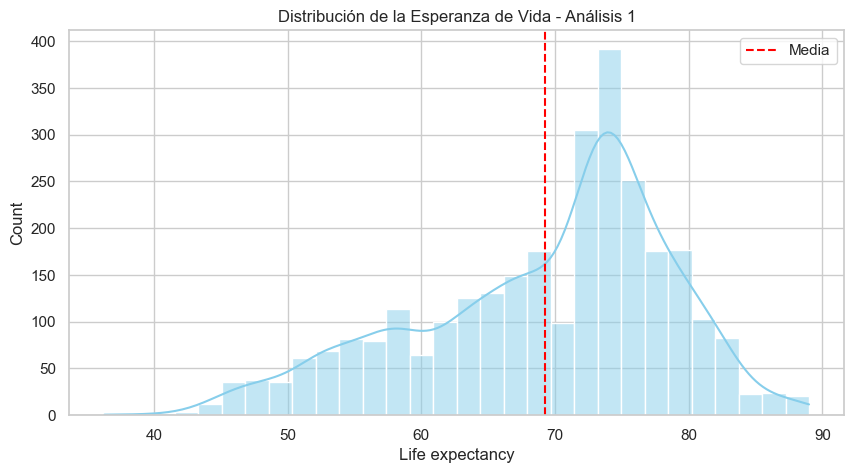

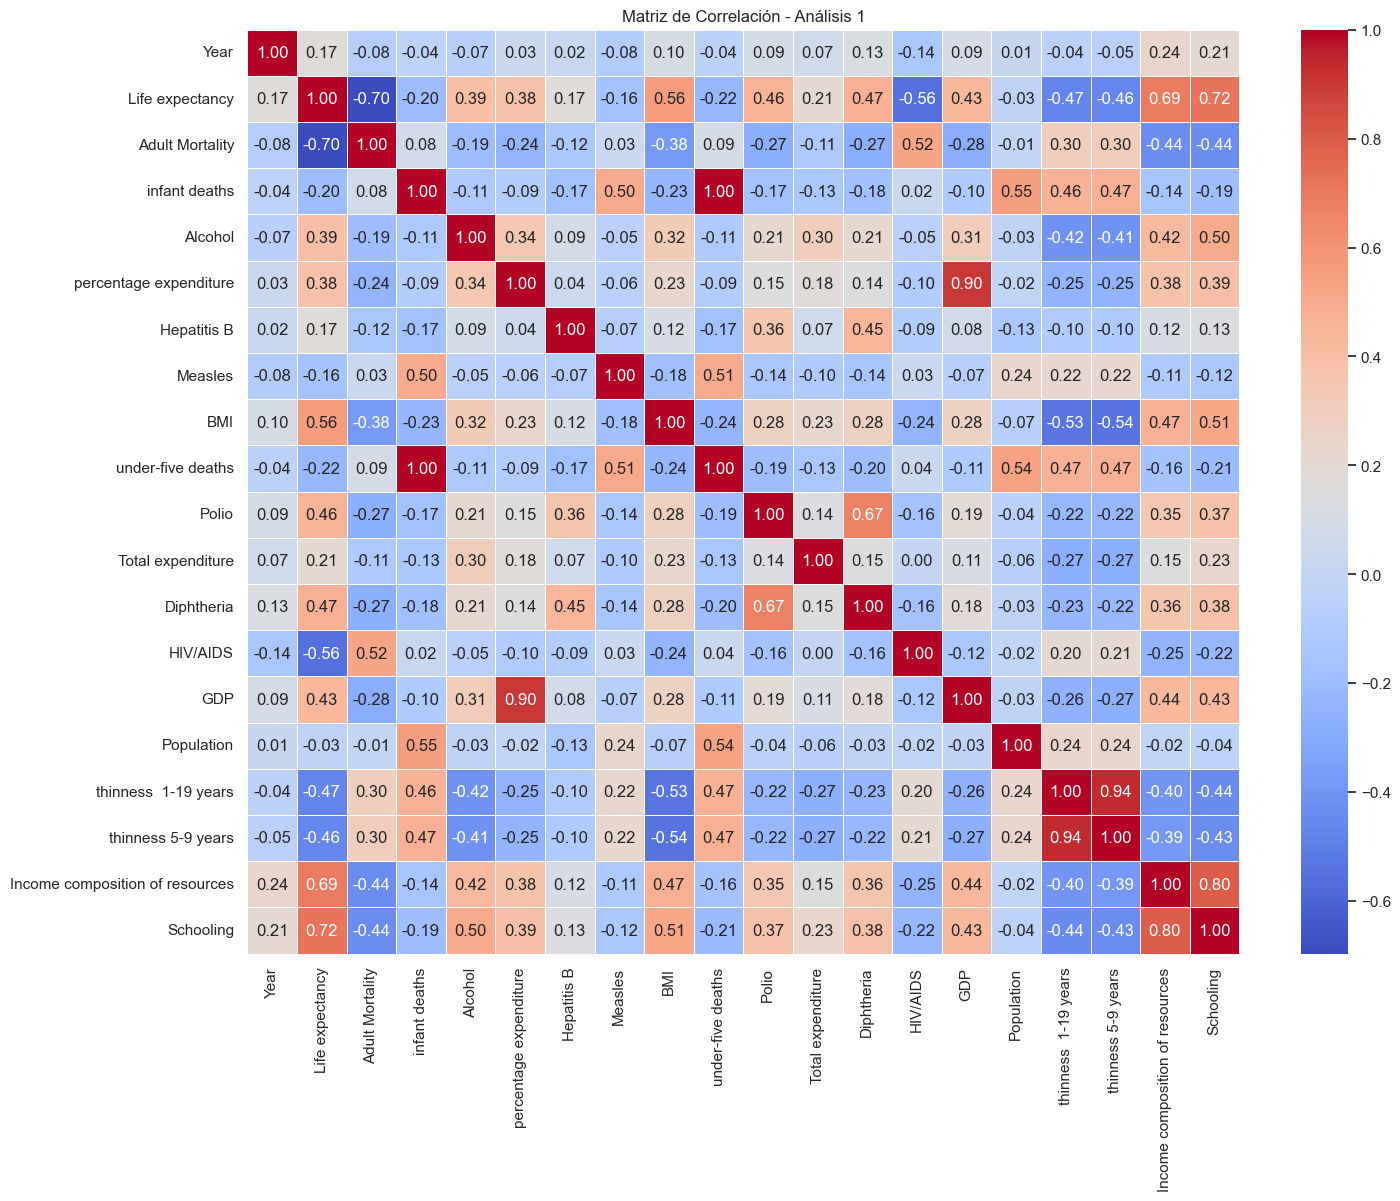

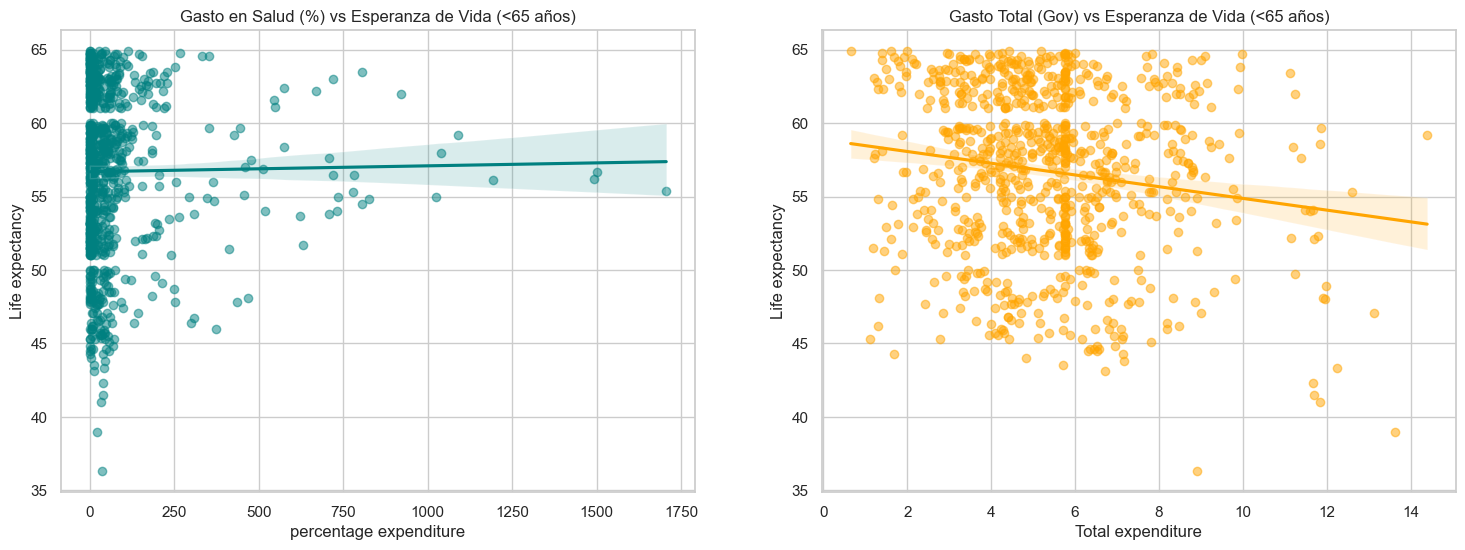

✅ Análisis exploratorio 1 completado.


In [3]:
# =============================================================================
# ANÁLISIS 1 - JOAQUÍN: Análisis Completo con Random Forest Optimizado
# =============================================================================

print("🔬 INICIANDO ANÁLISIS 1 - JOAQUÍN")
print("=" * 60)

# Preparación de datos para EDA (imputación temporal)
df_eda_v1 = df_clean.copy()
numeric_cols_v1 = df_eda_v1.select_dtypes(include=np.number).columns
for col in numeric_cols_v1:
    df_eda_v1[col] = df_eda_v1[col].fillna(df_eda_v1[col].median())

# Visualización de la distribución del target
plt.figure(figsize=(10, 5))
sns.histplot(df_eda_v1['Life expectancy'], kde=True, color='skyblue')
plt.title('Distribución de la Esperanza de Vida - Análisis 1')
plt.axvline(df_eda_v1['Life expectancy'].mean(), color='red', linestyle='--', label='Media')
plt.legend()
plt.show()

# Matriz de correlación
plt.figure(figsize=(16, 12))
corr_matrix_v1 = df_eda_v1.corr(numeric_only=True)
sns.heatmap(corr_matrix_v1, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación - Análisis 1')
plt.show()

# Análisis específico: países con baja esperanza de vida
low_le_v1 = df_eda_v1[df_eda_v1['Life expectancy'] < 65]

fig, ax = plt.subplots(1, 2, figsize=(18, 6))
sns.regplot(x='percentage expenditure', y='Life expectancy', data=low_le_v1, ax=ax[0], 
            scatter_kws={'alpha':0.5}, color='teal')
ax[0].set_title('Gasto en Salud (%) vs Esperanza de Vida (<65 años)')

sns.regplot(x='Total expenditure', y='Life expectancy', data=low_le_v1, ax=ax[1], 
            scatter_kws={'alpha':0.5}, color='orange')
ax[1].set_title('Gasto Total (Gov) vs Esperanza de Vida (<65 años)')
plt.show()

print("✅ Análisis exploratorio 1 completado.")


##### 3.2 Modelado - Integrante (Joaquín)


🤖 ENTRENANDO MODELO 1 - Random Forest Optimizado
Features modelo 1: 17 variables
--- TRAIN MODELO 1 ---
RMSE: 0.6859
MAE:  0.4286
R²:   0.9949
--- TEST MODELO 1 ---
RMSE: 1.7120
MAE:  1.0460
R²:   0.9661


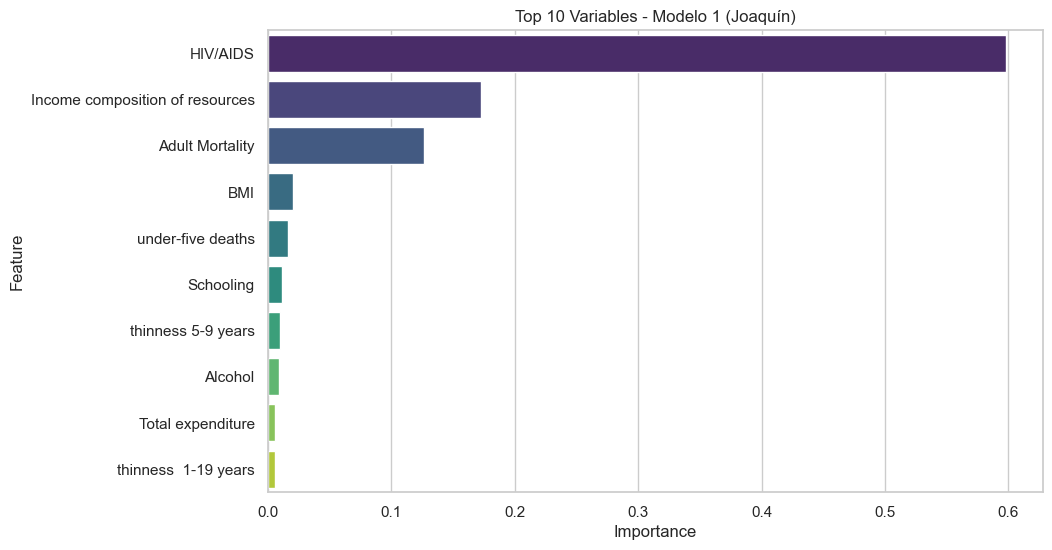

✅ Modelo 1 entrenado correctamente.


In [4]:
# MODELADO - ANÁLISIS 1 (JOAQUÍN)
print("\n🤖 ENTRENANDO MODELO 1 - Random Forest Optimizado")

# Feature Selection basada en correlación
features_to_drop_v1 = [
    'Life expectancy',        # Target
    'Country',                # Categórica con alta cardinalidad
    'Year',                   # No temporal
    'under-five deaths ',     # Redundante con infant deaths
    'percentage expenditure', # Redundante con GDP
    ' thinness 5-9 years',    # Redundante con thinness 1-19
    'Population'              # Baja correlación
]

X_v1 = df_clean.drop(features_to_drop_v1, axis=1, errors='ignore')
y_v1 = df_clean['Life expectancy']

print(f"Features modelo 1: {X_v1.shape[1]} variables")

# Train/Test Split
X_train_v1, X_test_v1, y_train_v1, y_test_v1 = train_test_split(
    X_v1, y_v1, test_size=0.2, random_state=42
)

# Pipeline de preprocesamiento
numeric_features_v1 = X_v1.select_dtypes(include=['int64', 'float64']).columns
categorical_features_v1 = X_v1.select_dtypes(include=['object', 'category']).columns

numeric_transformer_v1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer_v1 = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_v1 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_v1, numeric_features_v1),
        ('cat', categorical_transformer_v1, categorical_features_v1)
    ])

# Random Forest Pipeline
rf_pipeline_v1 = Pipeline(steps=[
    ('preprocessor', preprocessor_v1),
    ('regressor', RandomForestRegressor(random_state=42))
])

# GridSearch
param_grid_v1 = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [10, 20, None],
    'regressor__min_samples_split': [2, 5],
    'regressor__min_samples_leaf': [1, 2]
}

grid_search_v1 = GridSearchCV(rf_pipeline_v1, param_grid_v1, cv=5, scoring='r2', n_jobs=-1)
grid_search_v1.fit(X_train_v1, y_train_v1)

modelo_v1 = grid_search_v1.best_estimator_

# Evaluación
y_train_pred_v1 = modelo_v1.predict(X_train_v1)
y_test_pred_v1 = modelo_v1.predict(X_test_v1)

def evaluate_model_v1(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {set_name} ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R²:   {r2:.4f}")
    return r2

r2_train_v1 = evaluate_model_v1(y_train_v1, y_train_pred_v1, "TRAIN MODELO 1")
r2_test_v1 = evaluate_model_v1(y_test_v1, y_test_pred_v1, "TEST MODELO 1")

# Feature Importance
try:
    ohe_cols_v1 = modelo_v1.named_steps['preprocessor'].transformers_[1][1]['onehot'].get_feature_names_out(categorical_features_v1)
    feature_names_v1 = np.r_[numeric_features_v1, ohe_cols_v1]
    importances_v1 = modelo_v1.named_steps['regressor'].feature_importances_
    
    feat_imp_v1 = pd.DataFrame({'Feature': feature_names_v1, 'Importance': importances_v1})
    feat_imp_v1 = feat_imp_v1.sort_values(by='Importance', ascending=False).head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feat_imp_v1, palette='viridis')
    plt.title('Top 10 Variables - Modelo 1 (Joaquín)')
    plt.show()
except Exception as e:
    print(f"No se pudo mostrar feature importance: {e}")

print("✅ Modelo 1 entrenado correctamente.")


### 4. Preguntas 3 & 4
###### **3. ¿Cómo afectan las tasas de mortalidad infantil y adulta a la esperanza de vida?**

###### **4. ¿Tiene la esperanza de vida una correlación positiva o negativa con los hábitos alimenticios, el estilo de vida, el ejercicio, el consumo de tabaco, el consumo de alcohol, etc.?**

##### 4.1 EDA y Análisis - Integrante (Isa)

🔬 INICIANDO ANÁLISIS 4 - ISA
Columnas limpias - Análisis 4:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


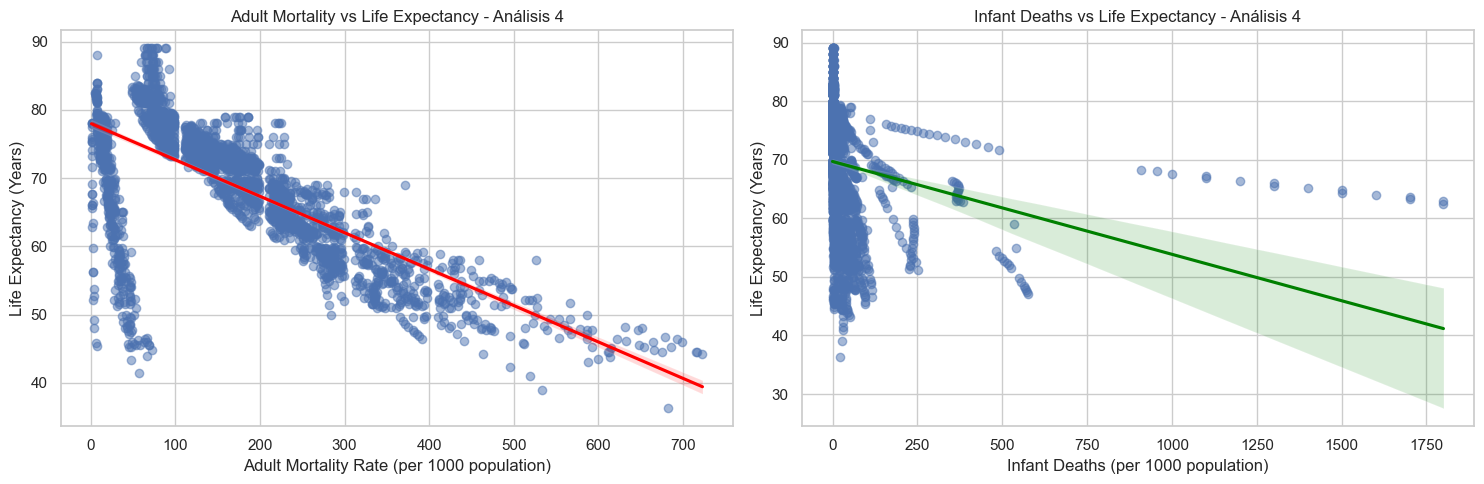

Correlación Adult Mortality vs Life expectancy: -0.70
Correlación Infant Deaths vs Life expectancy: -0.20


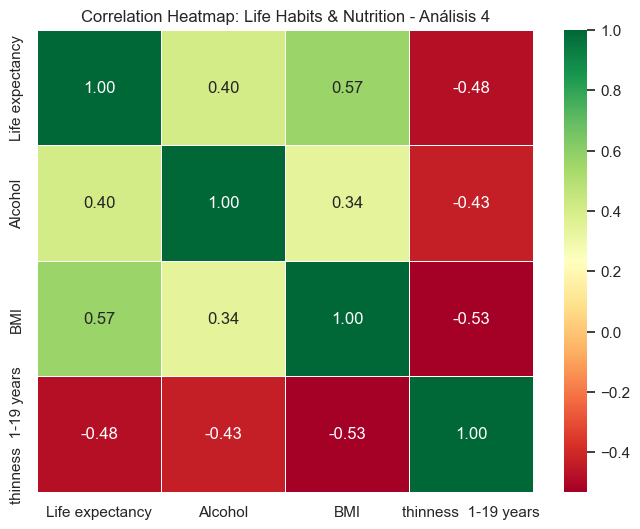

✅ Análisis exploratorio 4 completado.


In [5]:
# =============================================================================
# ANÁLISIS 4 - ISA: Enfoque en Mortalidad y Hábitos de Vida
# =============================================================================

print("🔬 INICIANDO ANÁLISIS 4 - ISA")
print("=" * 60)

# Preparación específica para análisis 4
df_v4 = df_clean.copy()
df_v4.columns = df_v4.columns.str.strip()

print("Columnas limpias - Análisis 4:")
print(df_v4.columns.tolist())

# Análisis específico: Mortalidad vs Esperanza de Vida
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.regplot(data=df_v4, x='Adult Mortality', y='Life expectancy', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Adult Mortality vs Life Expectancy - Análisis 4')
plt.xlabel('Adult Mortality Rate (per 1000 population)')
plt.ylabel('Life Expectancy (Years)')

plt.subplot(1, 2, 2)
sns.regplot(data=df_v4, x='infant deaths', y='Life expectancy', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
plt.title('Infant Deaths vs Life Expectancy - Análisis 4')
plt.xlabel('Infant Deaths (per 1000 population)')
plt.ylabel('Life Expectancy (Years)')

plt.tight_layout()
plt.show()

# Cálculo de correlaciones específicas
df_clean_mortalidad_v4 = df_v4.dropna(subset=['Life expectancy', 'Adult Mortality', 'infant deaths'])

corr_adulta_v4 = df_clean_mortalidad_v4['Adult Mortality'].corr(df_clean_mortalidad_v4['Life expectancy'])
corr_infantil_v4 = df_clean_mortalidad_v4['infant deaths'].corr(df_clean_mortalidad_v4['Life expectancy'])

print(f"Correlación Adult Mortality vs Life expectancy: {corr_adulta_v4:.2f}")
print(f"Correlación Infant Deaths vs Life expectancy: {corr_infantil_v4:.2f}")

# Análisis de hábitos de vida
columnas_habitos_v4 = ['Life expectancy', 'Alcohol', 'BMI']

# Buscar columna thinness (puede tener espacios variables)
thinness_col = None
for col in df_v4.columns:
    if 'thinness' in col and '1-19' in col:
        thinness_col = col
        break

if thinness_col:
    columnas_habitos_v4.append(thinness_col)

try:
    corr_habitos_v4 = df_v4[columnas_habitos_v4].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_habitos_v4, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
    plt.title('Correlation Heatmap: Life Habits & Nutrition - Análisis 4')
    plt.show()
except Exception as e:
    print(f"Error en matriz de correlación hábitos: {e}")

print("✅ Análisis exploratorio 4 completado.")


##### 4.2 Modelado - Integrante (Isa)

In [6]:
# MODELADO - ANÁLISIS 4 (ISA)
print("\n🤖 ENTRENANDO MODELO 4 - Modelo enfocado en Mortalidad")

# Preparación de datos con enfoque en mortalidad y hábitos
features_mortalidad_v4 = ['Adult Mortality', 'infant deaths', 'Alcohol', 'BMI', 'Status']

# Agregar thinness si existe
if thinness_col and thinness_col in df_v4.columns:
    features_mortalidad_v4.append(thinness_col)

# Encoding de Status
df_v4['Status_encoded'] = df_v4['Status'].map({'Developed': 1, 'Developing': 0}).fillna(0)
features_mortalidad_v4.append('Status_encoded')
features_mortalidad_v4.remove('Status')

# Selección de features disponibles
available_features_v4 = [col for col in features_mortalidad_v4 if col in df_v4.columns]
X_v4 = df_v4[available_features_v4].copy()
y_v4 = df_v4['Life expectancy']

# Imputación de nulos
for col in X_v4.select_dtypes(include=[np.number]).columns:
    X_v4[col] = X_v4[col].fillna(X_v4[col].median())

# Train/Test Split
X_train_v4, X_test_v4, y_train_v4, y_test_v4 = train_test_split(
    X_v4, y_v4, test_size=0.2, random_state=42
)

# Entrenamiento con Linear Regression
modelo_v4 = LinearRegression()
modelo_v4.fit(X_train_v4, y_train_v4)

# Predicciones
y_pred_v4 = modelo_v4.predict(X_test_v4)

# Evaluación
r2_v4 = r2_score(y_test_v4, y_pred_v4)
mae_v4 = mean_absolute_error(y_test_v4, y_pred_v4)

print(f"\n=== Resultados Modelo 4 ===")
print(f"R² (Precisión): {r2_v4:.4f}")
print(f"MAE: {mae_v4:.2f} años")
print(f"Features utilizadas: {available_features_v4}")

print("✅ Modelo 4 entrenado correctamente.")



🤖 ENTRENANDO MODELO 4 - Modelo enfocado en Mortalidad

=== Resultados Modelo 4 ===
R² (Precisión): 0.6400
MAE: 3.92 años
Features utilizadas: ['Adult Mortality', 'infant deaths', 'Alcohol', 'BMI', 'thinness  1-19 years', 'Status_encoded']
✅ Modelo 4 entrenado correctamente.


### 5. Preguntas 5 & 6
###### **5. ¿Cuál es el impacto de la escolaridad en la duración de la vida humana?**

###### **6. ¿Tiene la esperanza de vida una relación positiva o negativa con el consumo de alcohol?**

##### 5.1 EDA y Análisis - Integrante (Mar)

🔬 INICIANDO ANÁLISIS 3 - MAR
Nulos restantes: 0
Países con escolaridad 0: 26


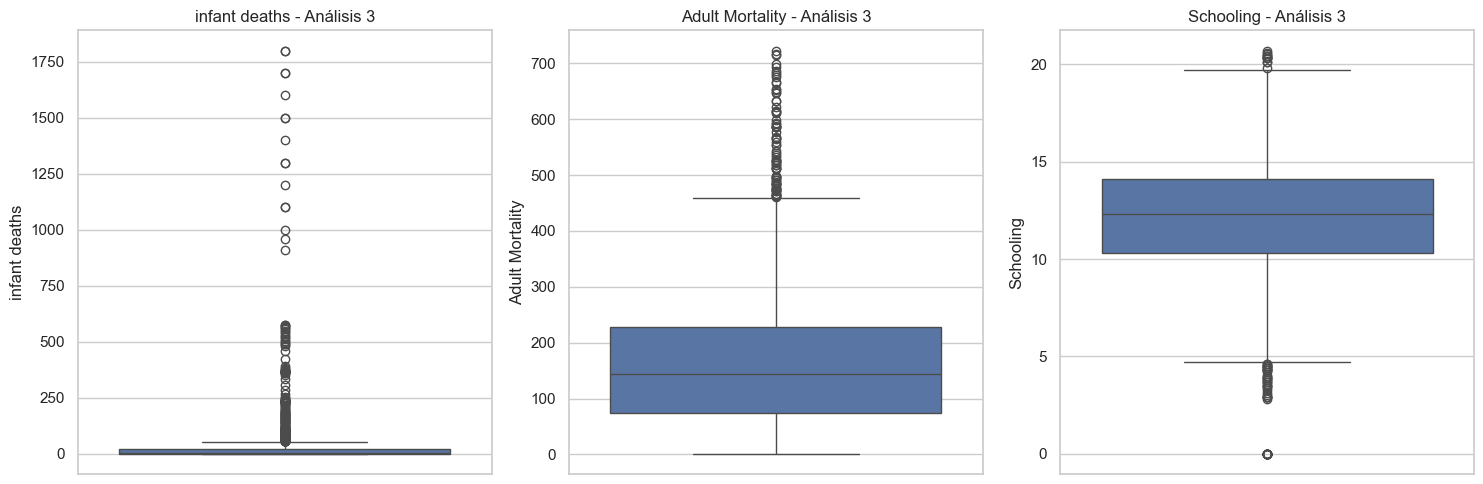

Registros restantes tras limpiar outliers: 2861


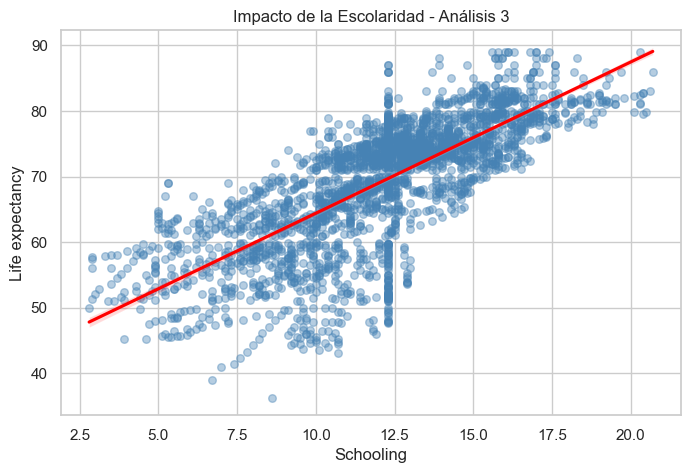

Correlación Schooling-Life expectancy: 0.75


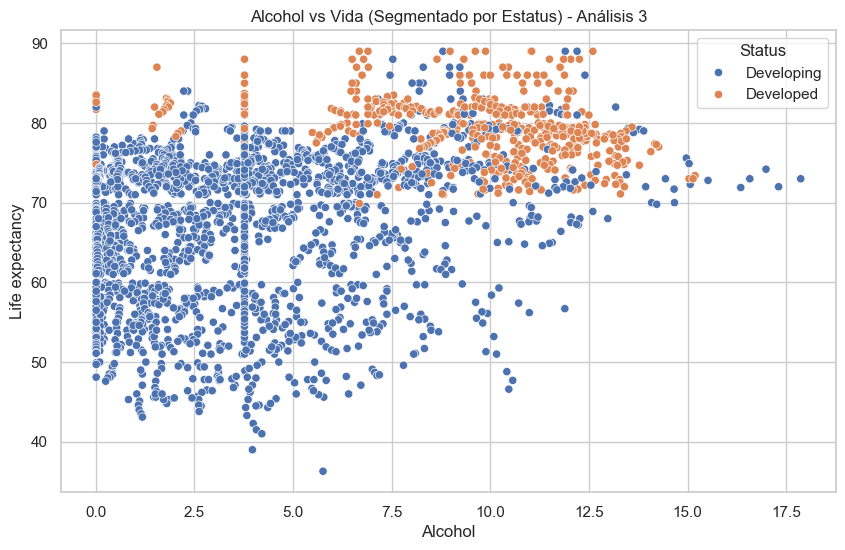

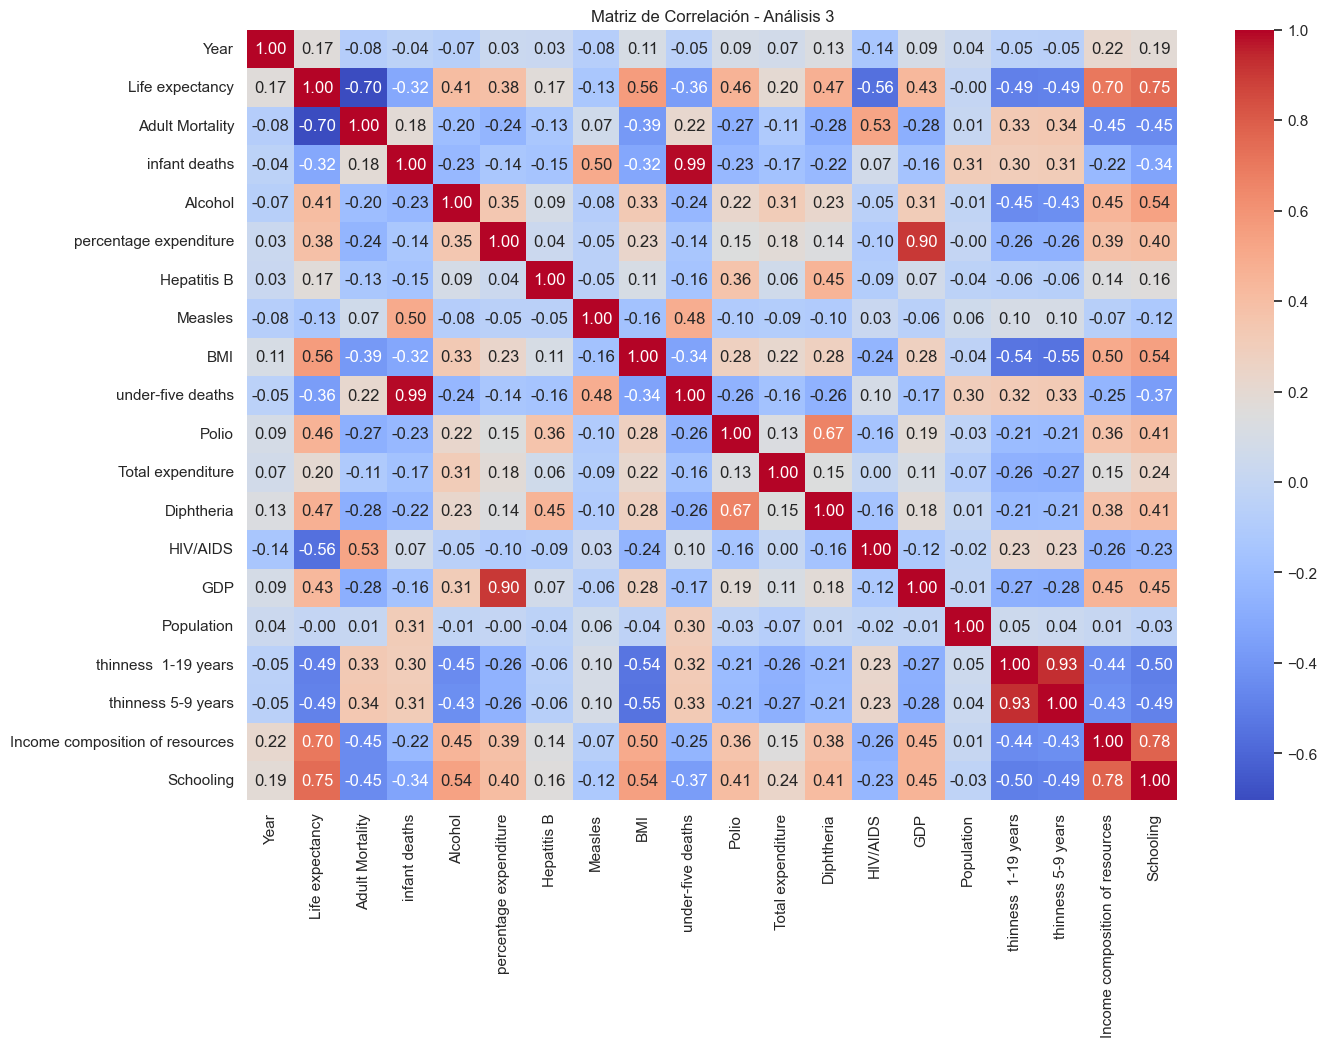

✅ Análisis exploratorio 3 completado.


In [7]:
# =============================================================================
# ANÁLISIS 3 - MAR: Enfoque en Outliers y Variables Clave
# =============================================================================

print("🔬 INICIANDO ANÁLISIS 3 - MAR")
print("=" * 60)

# Preparación específica para análisis 3
df_v3 = df_clean.copy()
df_v3.columns = df_v3.columns.str.strip()

# Imputación estratégica con mediana
columnas_con_nulos_v3 = ['Alcohol', 'Schooling', 'Hepatitis B', 'BMI', 'Polio', 
                         'Total expenditure', 'Diphtheria', 'GDP', 'Population', 
                         'Income composition of resources','thinness  1-19 years', 'thinness 5-9 years']

for col in columnas_con_nulos_v3:
    if col in df_v3.columns:
        df_v3[col] = df_v3[col].fillna(df_v3[col].median())

print(f"Nulos restantes: {df_v3.isnull().sum().sum()}")

# Análisis de outliers
print(f"Países con escolaridad 0: {len(df_v3[df_v3['Schooling'] == 0])}")

cols_to_check_v3 = ['infant deaths', 'Adult Mortality', 'Schooling']
plt.figure(figsize=(15, 5))
for i, col in enumerate(cols_to_check_v3):
    if col in df_v3.columns:
        plt.subplot(1, 3, i+1)
        sns.boxplot(y=df_v3[col])
        plt.title(f'{col} - Análisis 3')
plt.tight_layout()
plt.show()

# Limpieza de outliers
df_v3 = df_v3[df_v3['Schooling'] > 0]
df_v3 = df_v3[df_v3['Adult Mortality'] > 1]
limite_superior_infant_v3 = df_v3['infant deaths'].quantile(0.99)
df_v3 = df_v3[df_v3['infant deaths'] <= limite_superior_infant_v3]

print(f"Registros restantes tras limpiar outliers: {df_v3.shape[0]}")

# Análisis específico: Escolaridad vs Esperanza de Vida
plt.figure(figsize=(8, 5))
sns.regplot(data=df_v3, x='Schooling', y='Life expectancy', line_kws={'color':'red'}, 
            scatter_kws={'alpha': 0.4, 's': 30, 'color': 'steelblue'})
plt.title('Impacto de la Escolaridad - Análisis 3')
plt.show()

print(f"Correlación Schooling-Life expectancy: {df_v3['Schooling'].corr(df_v3['Life expectancy']):.2f}")

# Análisis segmentado por estatus
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_v3, x='Alcohol', y='Life expectancy', hue='Status')
plt.title('Alcohol vs Vida (Segmentado por Estatus) - Análisis 3')
plt.show()

# Mapa de correlación
plt.figure(figsize=(15, 10))
sns.heatmap(df_v3.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Análisis 3")
plt.show()

print("✅ Análisis exploratorio 3 completado.")


##### 5.2 Modelado - Integrante (Mar)

In [8]:
# MODELADO - ANÁLISIS 3 (MAR)
print("\n🤖 ENTRENANDO MODELO 3 - Linear Regression con Feature Engineering")

# Encoding de Status
df_v3['Status_encoded'] = df_v3['Status'].map({'Developed': 1, 'Developing': 0})

# Preparación de variables
X_v3 = df_v3.drop(['Life expectancy', 'Country', 'Status'], axis=1, errors='ignore')
y_v3 = df_v3['Life expectancy']

# Train/Test Split
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.2, random_state=42
)

print(f"Datos para entrenar modelo 3: {X_train_v3.shape[0]}")
print(f"Datos para probar modelo 3: {X_test_v3.shape[0]}")

# Entrenamiento
modelo_v3 = LinearRegression()
modelo_v3.fit(X_train_v3, y_train_v3)

# Predicciones
y_pred_v3 = modelo_v3.predict(X_test_v3)

# Evaluación
r2_v3 = r2_score(y_test_v3, y_pred_v3)
mae_v3 = mean_absolute_error(y_test_v3, y_pred_v3)

print(f"\n=== Resultados Modelo 3 ===")
print(f"R² (Precisión): {r2_v3:.4f}")
print(f"MAE: {mae_v3:.2f} años")

# Análisis de coeficientes
coeficientes_v3 = pd.DataFrame({'Variable': X_v3.columns, 'Impacto': modelo_v3.coef_})
print("\nTop Variables por Impacto:")
print(coeficientes_v3.sort_values(by='Impacto', ascending=False).head(10))

print("✅ Modelo 3 entrenado correctamente.")



🤖 ENTRENANDO MODELO 3 - Linear Regression con Feature Engineering
Datos para entrenar modelo 3: 2288
Datos para probar modelo 3: 573

=== Resultados Modelo 3 ===
R² (Precisión): 0.8196
MAE: 3.08 años

Top Variables por Impacto:
                           Variable   Impacto
17  Income composition of resources  6.726059
19                   Status_encoded  1.701258
18                        Schooling  0.759654
2                     infant deaths  0.164401
10                Total expenditure  0.121310
11                       Diphtheria  0.032701
7                               BMI  0.031216
9                             Polio  0.023786
16               thinness 5-9 years  0.005019
3                           Alcohol  0.001596
✅ Modelo 3 entrenado correctamente.


### 6. Pregunta 7 & 8
###### **7. ¿Tienden los países densamente poblados a tener una menor esperanza de vida?**

###### **8. ¿Cuál es el impacto de la cobertura de vacunación en la esperanza de vida?**

##### 6.1 EDA y Análisis - Integrante (Iris)

🔬 INICIANDO ANÁLISIS 2 - IRIS


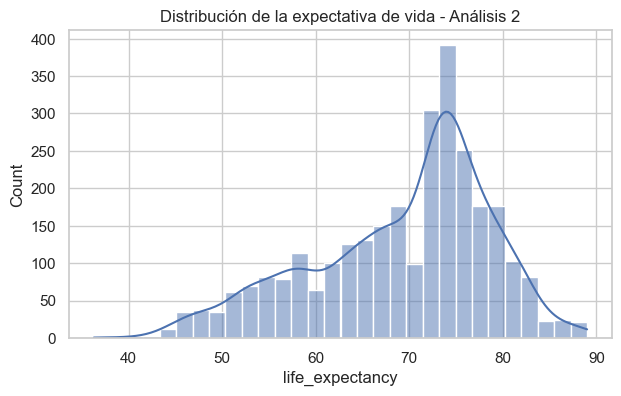

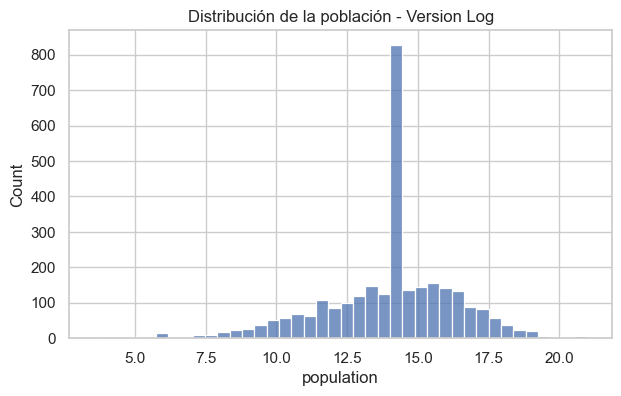

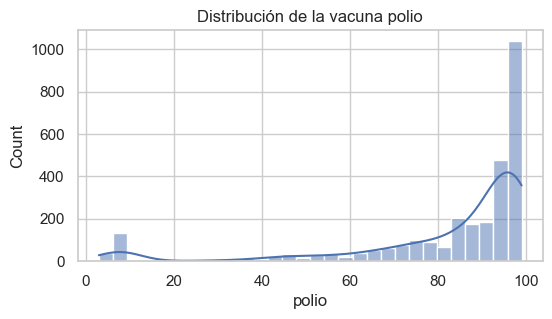

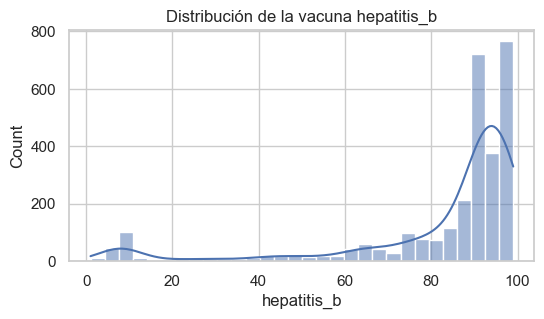

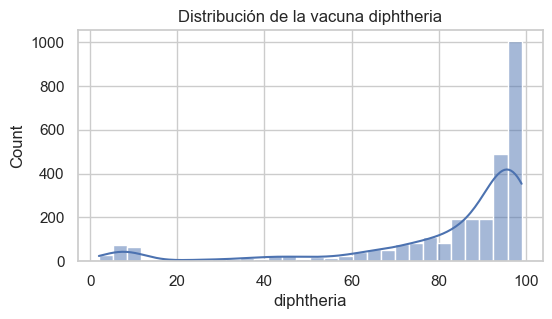

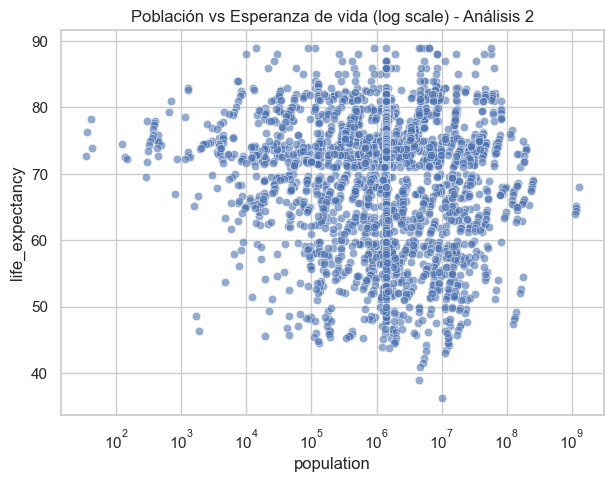

✅ Análisis exploratorio 2 completado.


In [9]:
# =============================================================================
# ANÁLISIS 2 - IRIS: Enfoque en Variables Categóricas y Escalado
# =============================================================================

print("🔬 INICIANDO ANÁLISIS 2 - IRIS")
print("=" * 60)

# Preparación específica para análisis 2
df_copy_v2 = df_clean.copy()

# Limpieza de nombres de columnas específica
df_copy_v2.columns = df_copy_v2.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('-', '_')

# Imputación con mediana para numéricas
num_cols_v2 = df_copy_v2.select_dtypes(include="number").columns
df_copy_v2[num_cols_v2] = df_copy_v2[num_cols_v2].fillna(df_copy_v2[num_cols_v2].median())

# Imputación con moda para categóricas
cat_cols_v2 = df_copy_v2.select_dtypes(include="object").columns
for col in cat_cols_v2:
    if col in df_copy_v2.columns:
        df_copy_v2[col] = df_copy_v2[col].fillna(df_copy_v2[col].mode()[0])

# Encoding de Status
status_map_v2 = {"developing": 0, "developed": 1}
df_copy_v2["status_num"] = (
    df_copy_v2["status"].str.strip().str.lower().map(status_map_v2)
).fillna(0).astype(float)

# Visualizaciones específicas del análisis 2
plt.figure(figsize=(7,4))
sns.histplot(df_copy_v2["life_expectancy"].dropna(), bins=30, kde=True)
plt.title("Distribución de la expectativa de vida - Análisis 2")
plt.show()

# Análisis de población con escala logarítmica
plt.figure(figsize=(7,4))
sns.histplot(np.log1p(df_copy_v2["population"].dropna()), bins=40)
plt.title("Distribución de la población - Version Log")
plt.show()

# Análisis de vacunas
vaccines_v2 = ["polio","hepatitis_b","diphtheria"]
for v in vaccines_v2:
    if v in df_copy_v2.columns:
        plt.figure(figsize=(6,3))
        sns.histplot(df_copy_v2[v].dropna(), bins=30, kde=True)
        plt.title(f"Distribución de la vacuna {v}")
        plt.show()

# Relación población vs esperanza de vida
plt.figure(figsize=(7,5))
sns.scatterplot(x=df_copy_v2["population"], y=df_copy_v2["life_expectancy"], alpha=0.6)
plt.xscale("log")
plt.title("Población vs Esperanza de vida (log scale) - Análisis 2")
plt.show()

print("✅ Análisis exploratorio 2 completado.")


##### 🟦 **Interpretación de los gráficos**

###### **Esperanza de vida**
###### *La distribución de la esperanza de vida presenta una forma aproximadamente normal, aunque con ligera asimetría hacia valores más bajos. La mayor parte de los países se concentran en un rango entre 60 y 80 años. Los valores extremadamente bajos suelen corresponder a países con problemas sanitarios graves, alta mortalidad infantil o crisis epidemiológicas.En general, la variable muestra suficiente variabilidad como para ser utilizada como variable objetivo en modelos predictivos.*

###### **Población**
###### *La variable población presenta una distribución extremadamente sesgada hacia la derecha. Existen pocos países con poblaciones muy grandes que generan valores atípicos muy altos, mientras que la mayoría de los países tienen poblaciones considerablemente menores. Debido a esta fuerte asimetría, resulta recomendable aplicar una transformación logarítmica antes de utilizar esta variable en análisis estadísticos o modelos predictivos. La población total por sí sola no representa directamente factores socioeconómicos ni la calidad del sistema sanitario.*

###### **Población vs Esperanza de vida**
###### *No se observa una relación clara ni fuerte entre el tamaño de la población y la esperanza de vida. Países con poblaciones muy grandes pueden presentar tanto valores altos como moderados de esperanza de vida, mientras que países con poblaciones pequeñas también muestran una gran variabilidad. Esto sugiere que la población total no es un factor determinante directo de la esperanza de vida. Factores como el desarrollo económico, la calidad del sistema sanitario, la educación y las políticas públicas tienen una influencia mucho mayor.*
###### **Conclusión: La población no debe considerarse un predictor principal de la esperanza de vida.**

###### **Cobertura de vacunación**
###### *Las variables de cobertura de vacunación muestran una fuerte concentración en valores altos, normalmente entre 80% y 100%. Esto indica que muchos países cuentan con programas de inmunización amplios y relativamente efectivos. Sin embargo, algunos países presentan coberturas significativamente más bajas, lo cual suele estar asociado a sistemas sanitarios débiles, menor acceso a servicios médicos o conflictos sociales. La presencia de valores bajos en vacunación sugiere posibles riesgos epidemiológicos y potencial impacto negativo en la salud pública.*

###### **Vacunación vs Esperanza de vida**
###### *Se observa una relación positiva entre la cobertura de vacunación y la esperanza de vida. Los países con mayores niveles de inmunización tienden a presentar mayores valores de esperanza de vida. Esto es coherente desde el punto de vista epidemiológico, ya que los programas de vacunación reducen la incidencia de enfermedades infecciosas, disminuyen la mortalidad infantil y mejoran la salud general de la población.*
###### **Conclusión: Por lo tanto, la cobertura de vacunación puede considerarse un indicador sanitario relevante y un factor importante asociado a la esperanza de vida.**



##### 6.2 Modelado - Integrante (Iris)

In [10]:
# MODELADO - ANÁLISIS 2 (IRIS)
print("\n🤖 ENTRENANDO MODELO 2 - Linear Regression + Random Forest")

# Preparación de datos
X_v2 = df_copy_v2.drop(["life_expectancy","country","status"], axis=1, errors='ignore')
y_v2 = df_copy_v2["life_expectancy"]

# Verificar ausencia de nulos
print(f"NaN en X_v2: {X_v2.isna().sum().sum()}")
print(f"NaN en y_v2: {y_v2.isna().sum()}")

# Train/Test Split
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42
)

# Modelo Linear Regression
modelo_lr_v2 = LinearRegression()
modelo_lr_v2.fit(X_train_v2, y_train_v2)
pred_lr_v2 = modelo_lr_v2.predict(X_test_v2)

print("=== Linear Regression - Modelo 2 ===")
print(f"R²: {r2_score(y_test_v2, pred_lr_v2):.4f}")
print(f"MAE: {mean_absolute_error(y_test_v2, pred_lr_v2):.4f}")

# Modelo Random Forest
modelo_rf_v2 = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
modelo_rf_v2.fit(X_train_v2, y_train_v2)
pred_rf_v2 = modelo_rf_v2.predict(X_test_v2)

print("\n=== Random Forest - Modelo 2 ===")
print(f"R²: {r2_score(y_test_v2, pred_rf_v2):.4f}")
print(f"MAE: {mean_absolute_error(y_test_v2, pred_rf_v2):.4f}")

# Seleccionamos el mejor modelo (Random Forest)
modelo_v2 = modelo_rf_v2

print("✅ Modelo 2 entrenado correctamente.")



🤖 ENTRENANDO MODELO 2 - Linear Regression + Random Forest
NaN en X_v2: 0
NaN en y_v2: 0
=== Linear Regression - Modelo 2 ===
R²: 0.8195
MAE: 2.9273

=== Random Forest - Modelo 2 ===
R²: 0.9672
MAE: 1.0498
✅ Modelo 2 entrenado correctamente.


### 7. Exportación de Modelos

In [11]:
# =============================================================================
# EXPORTACIÓN DE MODELOS
# =============================================================================

print("💾 GUARDANDO TODOS LOS MODELOS")
print("=" * 50)

# Crear carpeta models si no existe
os.makedirs('../../models', exist_ok=True)

# Guardar Modelo 1 (Joaquín - Random Forest con GridSearch)
try:
    joblib.dump(modelo_v1, '../../models/modelo_q1.pkl')
    print("✅ Modelo 1 (Joaquín) guardado como modelo_q1.pkl")
except:
    print("❌ Error al guardar modelo 1")

# Guardar Modelo 2 (Iris - Random Forest)
try:
    joblib.dump(modelo_v2, '../../models/modelo_q2.pkl')
    print("✅ Modelo 2 (Iris) guardado como modelo_q2.pkl")
except:
    print("❌ Error al guardar modelo 2")

# Guardar Modelo 3 (Mar - Linear Regression)
try:
    joblib.dump(modelo_v3, '../../models/modelo_q3.pkl')
    print("✅ Modelo 3 (Mar) guardado como modelo_q3.pkl")
except:
    print("❌ Error al guardar modelo 3")

# Guardar Modelo 4 (Isa - Linear Regression Mortalidad)
try:
    joblib.dump(modelo_v4, '../../models/modelo_q4.pkl')
    print("✅ Modelo 4 (Isa) guardado como modelo_q4.pkl")
except:
    print("❌ Error al guardar modelo 4")

# También guardamos las variables de entrenamiento para el widget
metadata = {
    'X_train_columns_v1': list(X_train_v1.columns),
    'X_train_columns_v2': list(X_train_v2.columns), 
    'X_train_columns_v3': list(X_train_v3.columns),
    'X_train_columns_v4': list(X_train_v4.columns),
    'available_features_v4': available_features_v4
}

joblib.dump(metadata, '../../models/models_metadata.pkl')
print("✅ Metadata de modelos guardada")
print("\n🎉 TODOS LOS MODELOS EXPORTADOS CORRECTAMENTE")


💾 GUARDANDO TODOS LOS MODELOS
✅ Modelo 1 (Joaquín) guardado como modelo_q1.pkl
✅ Modelo 2 (Iris) guardado como modelo_q2.pkl
✅ Modelo 3 (Mar) guardado como modelo_q3.pkl
✅ Modelo 4 (Isa) guardado como modelo_q4.pkl
✅ Metadata de modelos guardada

🎉 TODOS LOS MODELOS EXPORTADOS CORRECTAMENTE


### 8. Calculadora Integrada (Widget)

In [12]:
# =============================================================================
# CALCULADORA INTEGRADA - WIDGET INTERACTIVO
# =============================================================================

print("🏥 SIMULADOR INTEGRADO DE ESPERANZA DE VIDA")
print("=" * 60)

# Cargar todos los modelos
try:
    modelo_q1 = joblib.load('../../models/modelo_q1.pkl')
    modelo_q2 = joblib.load('../../models/modelo_q2.pkl') 
    modelo_q3 = joblib.load('../../models/modelo_q3.pkl')
    modelo_q4 = joblib.load('../../models/modelo_q4.pkl')
    metadata = joblib.load('../../models/models_metadata.pkl')
    print("✅ Todos los modelos cargados correctamente")
except Exception as e:
    print(f"❌ Error cargando modelos: {e}")
    print("Ejecuta primero la celda de exportación de modelos")

# Definir widgets
style = {'description_width': 'initial'}

w_modelo = widgets.Dropdown(
    options=[('Modelo 1 - Random Forest (Joaquín)', 1),
             ('Modelo 2 - Random Forest (Iris)', 2), 
             ('Modelo 3 - Linear Regression (Mar)', 3),
             ('Modelo 4 - Mortalidad Focus (Isa)', 4)],
    value=1,
    description='Seleccionar Modelo:',
    style=style
)

w_schooling = widgets.FloatSlider(value=10.0, min=0, max=21.0, step=0.1, 
                                  description='Años de Escolaridad:', style=style)
w_income = widgets.FloatSlider(value=0.5, min=0, max=1.0, step=0.01, 
                               description='Índice de Recursos (0-1):', style=style)
w_hiv = widgets.FloatSlider(value=0.1, min=0.1, max=50.0, step=0.1, 
                            description='VIH/SIDA (muertes/1000):', style=style)
w_adult_mort = widgets.IntSlider(value=200, min=0, max=1000, step=10, 
                                 description='Mortalidad Adultos:', style=style)
w_bmi = widgets.FloatSlider(value=40.0, min=10.0, max=80.0, step=0.1, 
                            description='BMI Promedio:', style=style)
w_gdp = widgets.FloatText(value=5000.0, description='PIB per Cápita ($):', style=style)
w_status = widgets.Dropdown(options=['Developing', 'Developed'], value='Developing', 
                            description='Estatus del País:', style=style)
w_polio = widgets.IntSlider(value=80, min=0, max=100, step=1, 
                            description='Vacunación Polio (%):', style=style)
w_alcohol = widgets.FloatSlider(value=4.5, min=0, max=20, step=0.1, 
                                description='Consumo Alcohol:', style=style)
w_infant_deaths = widgets.IntSlider(value=30, min=0, max=1000, step=5,
                                    description='Muertes Infantiles:', style=style)

button = widgets.Button(description="🔮 Predecir con Modelo Seleccionado", button_style='success')
button_all = widgets.Button(description="🚀 Predecir con TODOS los Modelos", button_style='info')
output = widgets.Output()

def crear_input_dataframe(modelo_num):
    """Crear DataFrame de entrada según el modelo seleccionado"""
    
    # Datos base comunes
    base_data = {
        'Status': [w_status.value],
        'Adult Mortality': [w_adult_mort.value],
        'infant deaths': [w_infant_deaths.value],
        'Alcohol': [w_alcohol.value],
        'Hepatitis B': [80],
        'Measles': [200],
        'BMI': [w_bmi.value],
        'Polio': [w_polio.value],
        'Total expenditure': [6.0],
        'Diphtheria': [w_polio.value],
        'HIV/AIDS': [w_hiv.value],
        'GDP': [w_gdp.value],
        'thinness  1-19 years': [4.8],
        'Income composition of resources': [w_income.value],
        'Schooling': [w_schooling.value],
        'Status_encoded': [1 if w_status.value == 'Developed' else 0]
    }
    
    # Ajustes específicos por modelo
    if modelo_num == 2:  # Iris (columnas en minúsculas con _)
        base_data_v2 = {}
        for key, value in base_data.items():
            new_key = key.lower().replace(' ', '_').replace('-', '_')
            base_data_v2[new_key] = value
        base_data_v2['year'] = [2015]  # Añadir año si es necesario
        return base_data_v2
    
    elif modelo_num == 4:  # Isa (solo features específicas)
        available_features = metadata['available_features_v4']
        filtered_data = {k: v for k, v in base_data.items() if k in available_features}
        return filtered_data
    
    return base_data

def predecir_modelo_individual(modelo_num):
    """Predecir con un modelo específico"""
    try:
        # Seleccionar modelo
        modelos = {1: modelo_q1, 2: modelo_q2, 3: modelo_q3, 4: modelo_q4}
        modelo = modelos[modelo_num]
        
        # Crear input
        data_input = crear_input_dataframe(modelo_num)
        input_df = pd.DataFrame(data_input)
        
        # Obtener columnas esperadas
        if modelo_num == 1:
            expected_cols = metadata['X_train_columns_v1']
        elif modelo_num == 2:
            expected_cols = metadata['X_train_columns_v2']
        elif modelo_num == 3:
            expected_cols = metadata['X_train_columns_v3']
        else:  # modelo_num == 4
            expected_cols = metadata['X_train_columns_v4']
        
        # Rellenar columnas faltantes con 0
        for col in expected_cols:
            if col not in input_df.columns:
                input_df[col] = 0
                
        # Reordenar columnas
        input_df = input_df.reindex(columns=expected_cols, fill_value=0)
        
        # Predicción
        prediction = modelo.predict(input_df)[0]
        return prediction
        
    except Exception as e:
        return f"Error: {str(e)}"

def on_single_predict(b):
    with output:
        clear_output()
        modelo_num = w_modelo.value
        nombre_modelo = w_modelo.label
        
        print(f"🔮 PREDICCIÓN CON {nombre_modelo}")
        print("=" * 50)
        
        prediction = predecir_modelo_individual(modelo_num)
        
        if isinstance(prediction, str):  # Error
            print(f"❌ {prediction}")
        else:
            print(f"📊 Esperanza de Vida Estimada: {prediction:.2f} años")
            print("-" * 30)
            
            if prediction < 65:
                print("⚠️ ALERTA: Esperanza de vida BAJA")
            elif prediction < 75:
                print("⚖️ ESTADO: Esperanza de vida MEDIA")
            else:
                print("✅ ESTADO: Esperanza de vida ALTA")

def on_all_predict(b):
    with output:
        clear_output()
        
        print("🚀 PREDICCIÓN CON TODOS LOS MODELOS")
        print("=" * 60)
        
        resultados = []
        nombres = ["Modelo 1 (Random Forest - Joaquín)", "Modelo 2 (Random Forest - Iris)", 
                   "Modelo 3 (Linear Regression - Mar)", "Modelo 4 (Mortalidad Focus - Isa)"]
        
        for i in range(1, 5):
            pred = predecir_modelo_individual(i)
            if isinstance(pred, str):
                print(f"❌ {nombres[i-1]}: {pred}")
            else:
                resultados.append(pred)
                print(f"📊 {nombres[i-1]}: {pred:.2f} años")
        
        if resultados:
            promedio = np.mean(resultados)
            print("\n" + "="*60)
            print(f"🎯 PREDICCIÓN PROMEDIO: {promedio:.2f} años")
            print(f"📈 Rango: {min(resultados):.2f} - {max(resultados):.2f} años")
            print(f"📊 Desviación estándar: {np.std(resultados):.2f} años")
            
            print("\n🏆 INTERPRETACIÓN CONSENSO:")
            if promedio < 65:
                print("⚠️ ALERTA: Esperanza de vida BAJA (Requiere intervención urgente)")
            elif promedio < 75:
                print("⚖️ ESTADO: Esperanza de vida MEDIA (Área de mejora)")
            else:
                print("✅ ESTADO: Esperanza de vida ALTA (Condiciones favorables)")

# Conectar eventos
button.on_click(on_single_predict)
button_all.on_click(on_all_predict)

# Interfaz
ui = widgets.VBox([
    widgets.HTML("<h3>🏥 Simulador Integrado de Esperanza de Vida</h3>"),
    w_modelo,
    widgets.HTML("<br><b>Parámetros de Entrada:</b>"),
    w_status, w_schooling, w_income, w_adult_mort, w_infant_deaths,
    w_bmi, w_gdp, w_hiv, w_polio, w_alcohol,
    widgets.HTML("<br><b>Predicciones:</b>"),
    button, button_all
])

display(ui, output)


🏥 SIMULADOR INTEGRADO DE ESPERANZA DE VIDA
✅ Todos los modelos cargados correctamente


Output()